# EXERCISE 1

## Imports

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff

## Constants

In [2]:
# Base directory
base_dir = "data/ex1_features"

# Song directories
song_dirs = sorted(
    [os.path.join(base_dir, d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])

## Read feature files

In [39]:
# Load all songs into a dict
song_data = {}

for song_path in song_dirs:
    song_name = os.path.basename(song_path)
    print(f"Loading {song_name}...")

    # Get all ARFF files
    arff_files = sorted([os.path.join(song_path, f) for f in os.listdir(song_path) if f.endswith(".arff")])

    dfs = []
    for f in arff_files:
        data, meta = arff.loadarff(f)
        df = pd.DataFrame(data)
        df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)
        df = df.apply(pd.to_numeric, errors='coerce')
        df.set_index('WindowNumber', inplace=True)
        dfs.append(df)

    # --- Merge horizontally, aligning by window number ---
    song_df = pd.concat(dfs, axis=1)

    song_data[song_name] = song_df

Loading classical...


/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_41988/2785366974.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


Loading electronic...


/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_41988/2785366974.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


Loading rock...


/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_41988/2785366974.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


In [40]:
print(song_data)

{'classical':               Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0                 0.025391      

## Plot features

1 plot x feature (containing data from the 3 songs

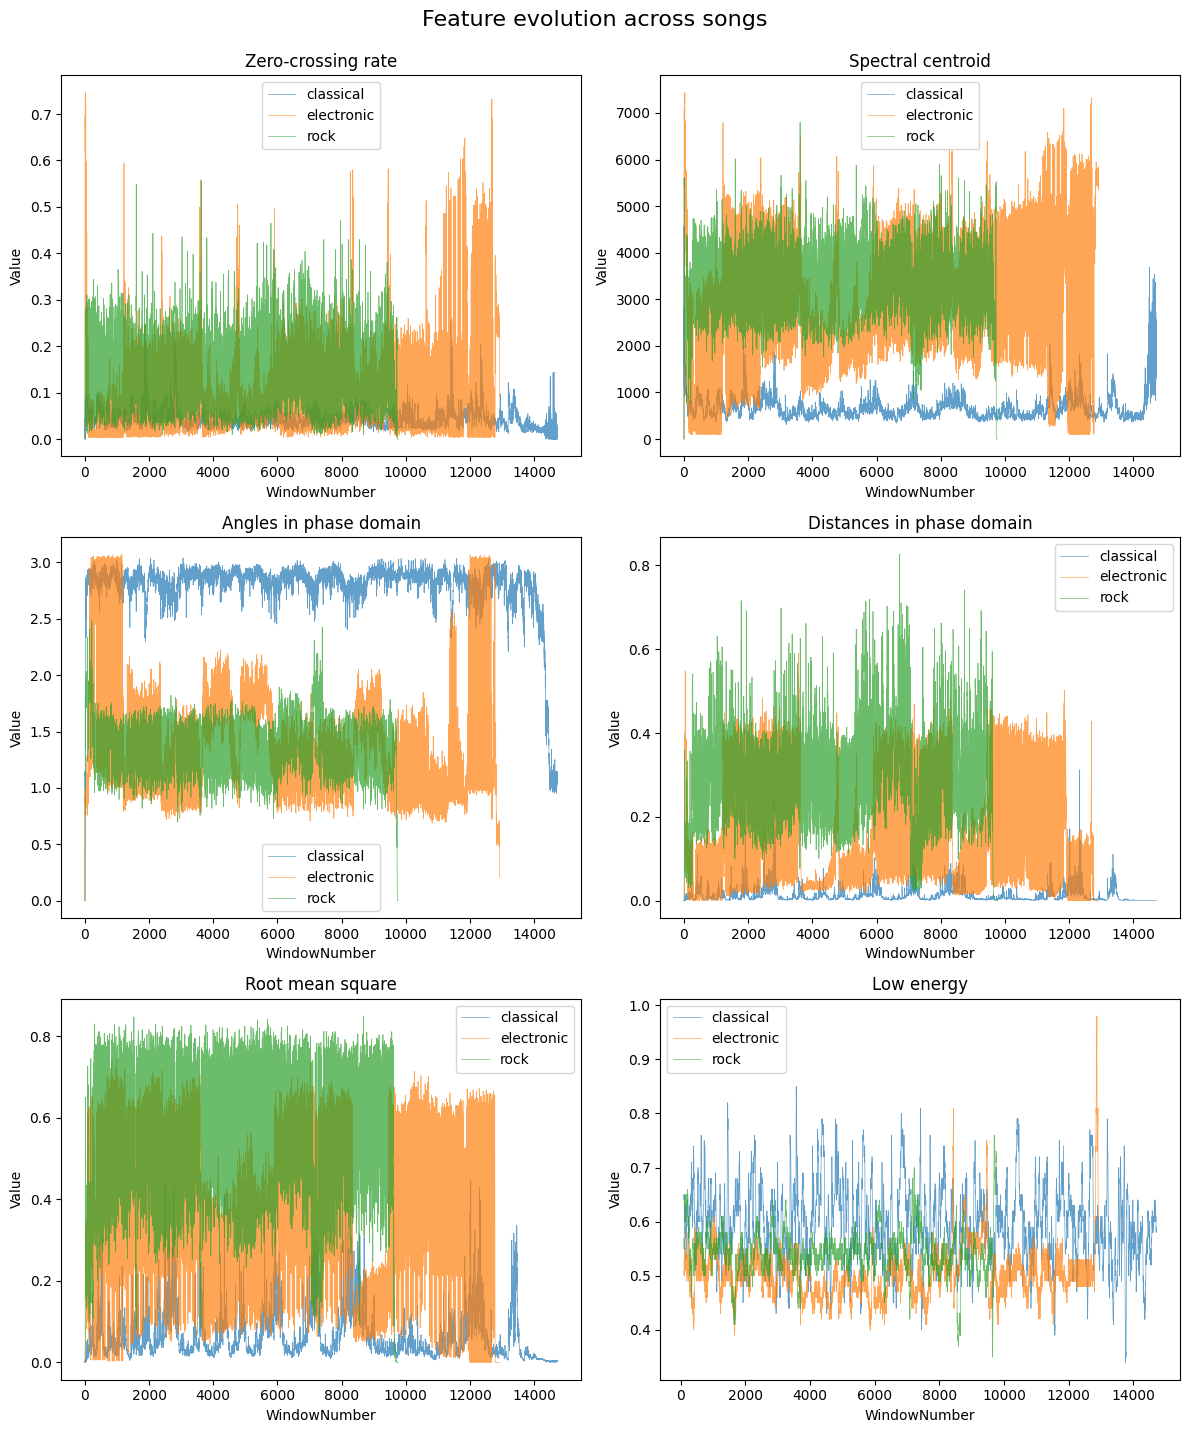

In [41]:
num_features = 6

# Identify feature names (assuming all songs share same structure)
features = list(next(iter(song_data.values())).columns[:num_features])  # first n features

# Plot one figure per feature, with 3 song curves
plt.figure(figsize=(12, 14))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 2, i)
    for song_name, df in song_data.items():
        plt.plot(df[feature].values, label=song_name, alpha=0.7, linewidth=0.5)
    plt.title(feature)
    plt.xlabel("WindowNumber")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()

plt.suptitle("Feature evolution across songs", fontsize=16, y=1.02)
plt.show()

In [42]:
from scipy.stats import pearsonr, spearmanr

features = ['Zero-crossing rate', 'Spectral centroid']

for song, df in song_data.items():
    df_clean = df[features]

    # Extract aligned feature vectors
    zcr = df_clean[features[0]]
    sc = df_clean[features[1]]

    pearson_corr, pearson_p = pearsonr(zcr, sc)
    spearman_corr, spearman_p = spearmanr(zcr, sc)

    print(f"\nCorrelations between ZCR and Spectral Centroid in {song}:")
    print(f"  Pearson  r = {pearson_corr:.4f}  (p = {pearson_p:.2e})")
    print(f"  Spearman ρ = {spearman_corr:.4f}  (p = {spearman_p:.2e})")


Correlations between ZCR and Spectral Centroid in classical:
  Pearson  r = 0.4191  (p = 0.00e+00)
  Spearman ρ = 0.7053  (p = 0.00e+00)

Correlations between ZCR and Spectral Centroid in electronic:
  Pearson  r = 0.8017  (p = 0.00e+00)
  Spearman ρ = 0.8494  (p = 0.00e+00)

Correlations between ZCR and Spectral Centroid in rock:
  Pearson  r = 0.7843  (p = 0.00e+00)
  Spearman ρ = 0.8074  (p = 0.00e+00)
